In [ ]:
from google.colab import drive
import joblib
import os

drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/Trained_Models"

# Load models
rf_model = joblib.load(os.path.join(save_path, "random_forest_model1.pkl"))
svm_model = joblib.load(os.path.join(save_path, "svm_model1.pkl"))
lr_model = joblib.load(os.path.join(save_path, "logistic_regression_model1.pkl"))

print(" Models loaded")


Mounted at /content/drive
 Models loaded


In [ ]:

from google.colab import drive
import pandas as pd
import os
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/Wednesday-workingHours.pcap_ISCX.csv"
data = pd.read_csv(file_path)

print(" Data loaded successfully!")
print("Shape:", data.shape)
df = pd.read_csv(file_path)
print("\nFirst 5 columns:", list(data.columns[:5]))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Data loaded successfully!
Shape: (692703, 85)

First 5 columns: ['Flow ID', ' Source IP', ' Source Port', ' Destination IP', ' Destination Port']


In [ ]:

import numpy as np
drop_cols = [
    'Flow ID', ' Source IP', ' Source Port',
    ' Destination IP', ' Destination Port', ' Protocol'
]
for col in drop_cols:
    if col in data.columns:
        data = data.drop(columns=col, errors='ignore')

# Keep only numeric features
data_num = data.select_dtypes(include=[np.number]).copy()

# Replace inf/nan values
data_num = data_num.replace([np.inf, -np.inf], np.nan).fillna(0)

print(" Data cleaned successfully! Shape:", data_num.shape)


✅ Data cleaned successfully! Shape: (692703, 77)


In [ ]:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_num)




In [ ]:

print(" Running model predictions...")

predictions = {
    "Random Forest": rf_model.predict,
    "SVM": svm_model.predict,
    "Logistic Regression": lr_model.predict
}

print("Predictions completed for all models!")


🚀 Running model predictions...
✅ Predictions completed for all models!


/tmp/ipython-input-3837777178.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Alert", data=alerts_df, palette=["blue", "red"])


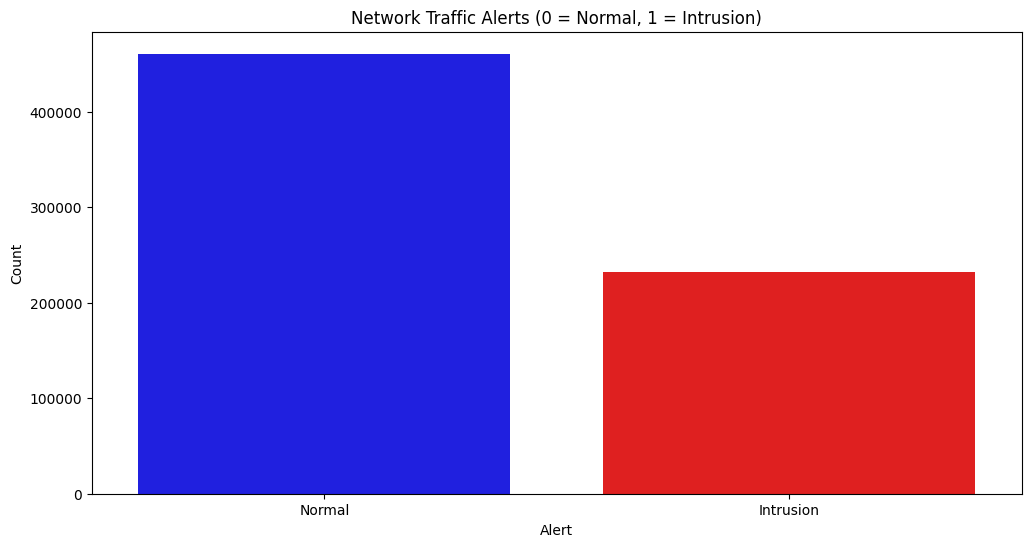

In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

# Plot normal vs alert
sns.countplot(x="Alert", data=alerts_df, palette=["blue", "red"])
plt.title("Network Traffic Alerts (0 = Normal, 1 = Intrusion)")
plt.xlabel("Alert")
plt.ylabel("Count")
plt.xticks([0,1], ["Normal", "Intrusion"])
plt.show()

# Optional: visualize alerts over time if Timestamp is available
if "Timestamp" in df.columns:
    plt.figure(figsize=(15,4))
    alerts_df['Timestamp'] = pd.to_datetime(alerts_df['Timestamp'], errors='coerce')
    plt.plot(alerts_df['Timestamp'], alerts_df['Alert'], '.', color='red', alpha=0.6)
    plt.title("Alerts Timeline")
    plt.xlabel("Timestamp")
    plt.ylabel("Alert (0=Normal,1=Intrusion)")
    plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# For better plots
sns.set(style="whitegrid")
%matplotlib inline


In [ ]:
print("Running model predictions...")

rf_preds = rf_model.predict(data_pca_rf)
svm_preds = svm_model.predict(data_pca_svm)
lr_preds = lr_model.predict(data_pca_lr)

# Convert to 0=Normal, 1=Alert
rf_preds = np.where(rf_preds==1, 1, 0)
svm_preds = np.where(svm_preds==1, 1, 0)
lr_preds = np.where(lr_preds==1, 1, 0)

# Create combined alert DataFrame
alerts_df = pd.DataFrame({
    "Random Forest": rf_preds,
    "SVM": svm_preds,
    "Logistic Regression": lr_preds
})

# Any alert
alerts_df['Any Alert'] = alerts_df.max(axis=1)

# Counts
total_records = len(alerts_df)
total_alerts = alerts_df['Any Alert'].sum()
alerts_percent = (total_alerts / total_records) * 100

print(f"Total Records      : {total_records}")
print(f"Total Alerts       : {total_alerts}")
print(f"Alerts Percentage  : {alerts_percent:.2f}%")


Running model predictions...
Total Records      : 692703
Total Alerts       : 231859
Alerts Percentage  : 33.47%


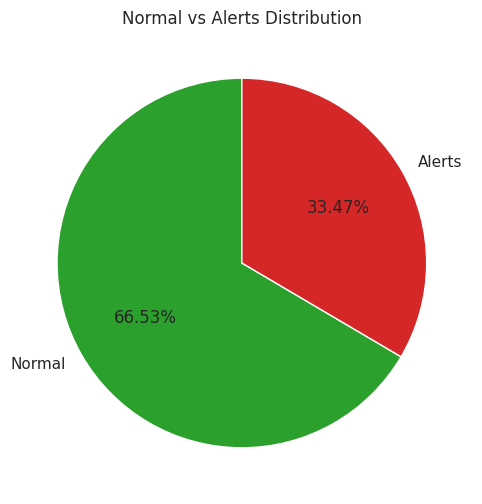

In [ ]:
plt.figure(figsize=(6,6))
plt.pie([total_records - total_alerts, total_alerts], labels=["Normal", "Alerts"],
        colors=["#2ca02c", "#d62728"], autopct='%1.2f%%', startangle=90)
plt.title("Normal vs Alerts Distribution")
plt.show()


/tmp/ipython-input-1499658897.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_alerts.index, y=model_alerts.values, palette=["#1f77b4", "#ff7f0e", "#2ca02c"])


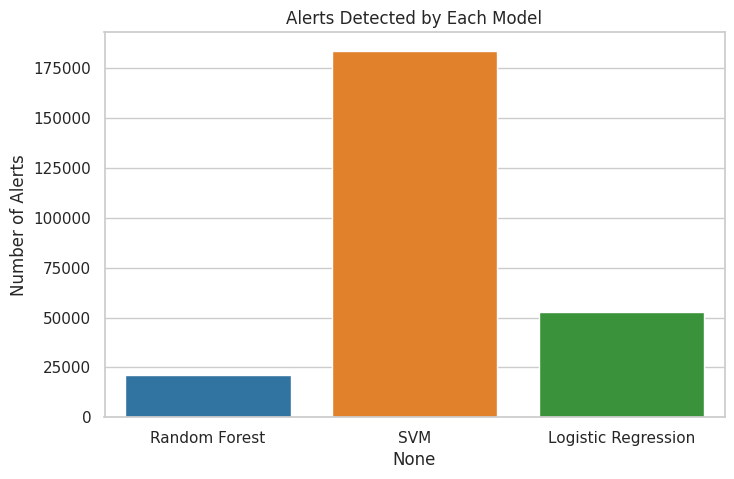

In [ ]:
model_alerts = alerts_df[["Random Forest", "SVM", "Logistic Regression"]].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=model_alerts.index, y=model_alerts.values, palette=["#1f77b4", "#ff7f0e", "#2ca02c"])
plt.ylabel("Number of Alerts")
plt.title("Alerts Detected by Each Model")
plt.show()
